In [1]:
import pandas as pd
from metrics import SyntheticDataEvaluator

In [2]:
# Change accordingly
data_original = pd.read_csv('../Data/data.csv')
data_ctgan = pd.read_csv('../Classical_Models/ctgan_data.csv')
data_datasynthesizer = pd.read_csv('../Classical_Models/datasythesizer_data.csv')
data_tvae = pd.read_csv('../Classical_Models/tvae_data.csv')
data_synthpop = pd.read_csv('../Classical_Models/synthpop_data.csv')

data_tabula_distil_1 = pd.read_csv('../LLM_based/TabuLa/tabula_data.csv')
data_tabula_gpt_1 = pd.read_csv('../LLM_based/TabuLa/tabula_data_gpt.csv')
data_tabula_middle_distil_1 = pd.read_csv('../LLM_based/TabuLa/tabula_data_middle.csv')
data_tabula_middle_gpt_1 = pd.read_csv('../LLM_based/TabuLa/tabula_data_middle_gpt.csv')
data_tabula_distil_2 = pd.read_csv('../LLM_based/TabuLa/tabula_data_v2.csv')
data_tabula_gpt_2 = pd.read_csv('../LLM_based/TabuLa/tabula_data_gpt_v2.csv')
data_tabula_middle_distil_2 = pd.read_csv('../LLM_based/TabuLa/tabula_data_middle_v2.csv')
data_tabula_middle_gpt_2 = pd.read_csv('../LLM_based/TabuLa/tabula_data_middle_gpt_v2.csv')

data_diana = pd.read_csv('../LLM_based/Diana/diana_data.csv')

data_great = pd.read_csv('../LLM_based/GReaT/great_data.csv')

In [5]:
data_original.head()

,customer_age_class,region,basket_package_price_disc,internet_package_price_disc,basket_days_until_contract_end,count_previous_cancellations_0_18,internet_product_name,flag_churn
0,70 - 74,NRW,64.95,54.97,366,0,3PLAY PREMIUM HRZ,0
1,35 - 39,HSN,44.98,44.98,100,0,RED INTERNET & PHONE CABLE U,1
2,35 - 39,NRW,54.98,54.98,30,0,RED INTERNET & PHONE CABLE U,1
3,35 - 39,HSN,209.84,209.84,30,0,VF CABLEMAX,1
4,25 - 29,NRW,63.98,63.98,123,0,GIGAZUHAUSE KABEL,1


More evaluation metrics here
https://dl.acm.org/doi/fullHtml/10.1145/3636555.3636921#:~:text=Distance%20to%20Closest%20Record%20(DCR,less%20risk%20of%20privacy%20leakage.

# Machine Learning Efficiency (MLE)

Since the generated data set should be able to replace the real data in a training process, the measure evaluates the performance of discriminative models trained on synthetic data sets.
Therefore, the models are tested on real test data, and the scores are compared to the original performance when the models were trained on the original, real training data set.
(First trained on real original dataset, then on the synthetic dataset and compare the results of the models on real test data.)

To be independent of the concrete discriminative model, we evaluated the synthetic data sets using a Linear/Logistic Regression (LR), a Decision Tree (DT) and a Random Forest (RF).

For classification tasks the accuracy score is reported, in the case of regression the mean squared error is used. Next to those we also report the ROCAUC score and the F1 score.  
**Results are averages over five trials with different random seeds**



We randpmöy split original data into training data (80%) and test data (20%). Then we initiate by training each algorithm on the training data and employ the trained model to generate synthetic data of an equivalent size. Subsequently, we train identical machine learning models twice - once employing the training data and once with the synthetic data. 

For classifiaction datasets, we employ five different models: 
- decision tree classification, 
- linear support-vector-machine (SVM), 
- random forest classifier, 
- multinomial logistic regression 
- multilayer perceptron (MLP).

For regression datasets, we select four models: linear regression, ridge regression, lasso regression and Bayesian ridge regression. 

Ultimately, the test set is used to independently assess each model pair trained on both original and synthetic data. We adopt the F1-score as the evaluation metric for classifiaction tasks and employ the mean absolute percentage error (MAPE) for regression tasks. The average score across all models is reported for each dataset.

### Classical Methods

In [3]:
# DON'T RUN
data_original = pd.get_dummies(data_original)
data_ctgan = pd.get_dummies(data_ctgan)
data_datasynthesizer = pd.get_dummies(data_datasynthesizer)
data_tvae = pd.get_dummies(data_tvae)
# Some datas had more columns than the other because the unique values in the column differed according to the data and one hot encoding was done differently

In [3]:
# So I joined all together
combined_df = pd.concat([data_original, data_ctgan, data_datasynthesizer, data_tvae, data_synthpop], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined_df)

data_original = combined_encoded.iloc[:10000, :]
data_ctgan = combined_encoded.iloc[10000:20000, :]
data_datasynthesizer = combined_encoded.iloc[20000:30000, :]
data_tvae = combined_encoded.iloc[30000:40000, :]
data_synthpop = combined_encoded.iloc[40000:, :]

In [4]:
evaluator_ctgan = SyntheticDataEvaluator(data_original, data_ctgan)
evaluator_datasynthesizer = SyntheticDataEvaluator(data_original, data_datasynthesizer)
evaluator_tvae = SyntheticDataEvaluator(data_original, data_tvae)
evaluator_synthpop = SyntheticDataEvaluator(data_original, data_synthpop)


In [5]:
mle_ctgan = evaluator_ctgan.mle(target_column = 'flag_churn', task_type = 'classification')
mle_datasynthesizer = evaluator_datasynthesizer.mle(target_column = 'flag_churn', task_type = 'classification')
mle_tvae = evaluator_tvae.mle(target_column = 'flag_churn', task_type = 'classification')
mle_synthpop = evaluator_synthpop.mle(target_column = 'flag_churn', task_type = 'classification')

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:22:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
   

In [6]:
mle_ctgan['data_datasynthesizer'] = mle_datasynthesizer['Synthetic Data']
mle_ctgan['data_tvae'] = mle_tvae['Synthetic Data']
mle_ctgan['data_synthpop'] = mle_synthpop['Synthetic Data']

mle_ctgan['comboned_data_datasynthesizer'] = mle_datasynthesizer['Original and Synthetic Data']
mle_ctgan['combined_data_tvae'] = mle_tvae['Original and Synthetic Data']
mle_ctgan['combined_data_synthpop'] = mle_synthpop['Original and Synthetic Data']

In [8]:
mle_ctgan.columns = ['Models', 'Original Data', 'CTGAN Data', 'Datasynthesizer Data', 'TVAE Data', 'Synthpop Data', 'CTGAN  Combined Data', 'Datasynthesizer Combined Data', 'TVAE Combined Data', 'Synthpop Combined Data']
mle_ctgan.transpose()

,0,1,2,3
Models,Logistic Regression,Decision Tree,Random Forest,XGBoost
Original Data,0.68,0.64,0.6585,0.6775
CTGAN Data,0.6065,0.616,0.6035,0.602
Datasynthesizer Data,0.6075,0.6445,0.6555,0.672
TVAE Data,0.6335,0.5885,0.6195,0.5995
Synthpop Data,0.659,0.6495,0.6545,0.6595
CTGAN Combined Data,0.5935,0.597,0.594,0.5935
Datasynthesizer Combined Data,0.6715,0.6415,0.6555,0.674
TVAE Combined Data,0.678,0.6385,0.6565,0.6615
Synthpop Combined Data,0.6395,0.6425,0.6655,0.6695


### LLM models

In [3]:
# So I joined all together
data_original = data_original.dropna()

data_tabula_distil_1 = data_tabula_distil_1.dropna()
data_tabula_gpt_1 = data_tabula_gpt_1.dropna()
data_tabula_middle_distil_1 = data_tabula_middle_distil_1.dropna()
data_tabula_middle_gpt_1 = data_tabula_middle_gpt_1.dropna()

data_tabula_distil_2 = data_tabula_distil_2.dropna()
data_tabula_gpt_2 = data_tabula_gpt_2.dropna()
data_tabula_middle_distil_2 = data_tabula_middle_distil_2.dropna()
data_tabula_middle_gpt_2 = data_tabula_middle_gpt_2.dropna()

combined_df = pd.concat([data_original, data_tabula_distil_1, data_tabula_gpt_1, data_tabula_middle_distil_1, data_tabula_middle_gpt_1, 
                        data_tabula_distil_2, data_tabula_gpt_2, data_tabula_middle_distil_2, data_tabula_middle_gpt_2], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined_df)

a = data_original.shape[0] 
b = a + data_tabula_distil_1.shape[0]
c = b + data_tabula_gpt_1.shape[0]
d = c + data_tabula_middle_distil_1.shape[0]
e = d + data_tabula_middle_gpt_1.shape[0]
f = e + data_tabula_distil_2.shape[0]
g = f + data_tabula_gpt_2.shape[0]
h = g + data_tabula_middle_distil_2.shape[0]
i = h + data_tabula_middle_gpt_2.shape[0]


data_original = combined_encoded.iloc[:a, :]
data_tabula_distil_1 = combined_encoded.iloc[a:b, :]
data_tabula_gpt_1 = combined_encoded.iloc[b:c, :]
data_tabula_middle_distil_1 = combined_encoded.iloc[c:d, :]
data_tabula_middle_gpt_1 = combined_encoded.iloc[d:e, :]
data_tabula_distil_2 = combined_encoded.iloc[e:f, :]
data_tabula_gpt_2 = combined_encoded.iloc[f:g, :]
data_tabula_middle_distil_2 = combined_encoded.iloc[g:h, :]
data_tabula_middle_gpt_2 = combined_encoded.iloc[h:i, :]

In [4]:
evaluator_data_tabula_distil_1 = SyntheticDataEvaluator(data_original, data_tabula_distil_1)
evaluator_data_tabula_gpt_1 = SyntheticDataEvaluator(data_original, data_tabula_gpt_1)
evaluator_data_tabula_middle_distil_1 = SyntheticDataEvaluator(data_original, data_tabula_middle_distil_1)
evaluator_data_tabula_middle_gpt_1 = SyntheticDataEvaluator(data_original, data_tabula_middle_gpt_1)

evaluator_data_tabula_distil_2 = SyntheticDataEvaluator(data_original, data_tabula_distil_2)
evaluator_data_tabula_gpt_2 = SyntheticDataEvaluator(data_original, data_tabula_gpt_2)
evaluator_data_tabula_middle_distil_2 = SyntheticDataEvaluator(data_original, data_tabula_middle_distil_2)
evaluator_data_tabula_middle_gpt_2 = SyntheticDataEvaluator(data_original, data_tabula_middle_gpt_2)

In [5]:
mle_data_tabula_distil_1 = evaluator_data_tabula_distil_1.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_gpt_1 = evaluator_data_tabula_gpt_1.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_middle_distil_1 = evaluator_data_tabula_middle_distil_1.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_middle_gpt_1 = evaluator_data_tabula_middle_gpt_1.mle_xgb(target_column = 'flag_churn', task_type = 'classification')

mle_data_tabula_distil_2 = evaluator_data_tabula_distil_2.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_gpt_2 = evaluator_data_tabula_gpt_2.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_middle_distil_2 = evaluator_data_tabula_middle_distil_2.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_middle_gpt_2 = evaluator_data_tabula_middle_gpt_2.mle_xgb(target_column = 'flag_churn', task_type = 'classification')

/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:47:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:47:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:47:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:47:38] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:47:38] WAR

In [6]:
mle_data_tabula_distil_1['data_tabula_gpt_1'] = mle_data_tabula_gpt_1['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_middle_distil_1'] = mle_data_tabula_middle_distil_1['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_middle_gpt_1'] = mle_data_tabula_middle_gpt_1['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_distil_2'] = mle_data_tabula_distil_2['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_gpt_2'] = mle_data_tabula_gpt_2['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_middle_distil_2'] = mle_data_tabula_middle_distil_2['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_middle_gpt_2'] = mle_data_tabula_middle_gpt_2['Synthetic Data']


mle_data_tabula_distil_1['comboned_data_tabula_gpt_1'] = mle_data_tabula_gpt_1['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_middle_distil_1'] = mle_data_tabula_middle_distil_1['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_middle_gpt_1'] = mle_data_tabula_middle_gpt_1['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_distil_2'] = mle_data_tabula_distil_2['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_gpt_2'] = mle_data_tabula_gpt_2['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_middle_distil_2'] = mle_data_tabula_middle_distil_2['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_middle_gpt_2'] = mle_data_tabula_middle_gpt_2['Original and Synthetic Data']

In [14]:
mle_data_tabula_distil_1.columns = ['Models', 'Original Data', 
                                    'data_tabula_distil_1 Data', 'data_tabula_gpt_1 Data', 
                                    'data_tabula_middle_distil_1 Data', 'data_tabula_middle_gpt_1 Data',
                                    'data_tabula_distil_2 Data', 'data_tabula_gpt_2 Data', 
                                    'data_tabula_middle_distil_2 Data', 'data_tabula_middle_gpt_2 Data',
                                    'data_tabula_distil_1 Combined Data', 'data_tabula_gpt_1 Combined Data', 
                                    'data_tabula_middle_distil_1 Combined Data', 'data_tabula_middle_gpt_1 Combined Data',
                                    'data_tabula_distil_2 Combined Data', 'data_tabula_gpt_2 Combined Data', 
                                    'data_tabula_middle_distil_2 Combined Data', 'data_tabula_middle_gpt_2 Combined Data']
mle_data_tabula_distil_1.transpose()

,0
Models,XGBoost
Original Data,0.6575
data_tabula_distil_1 Data,0.6035
data_tabula_gpt_1 Data,0.7145
data_tabula_middle_distil_1 Data,0.602
data_tabula_middle_gpt_1 Data,0.6615
data_tabula_distil_2 Data,0.64
data_tabula_gpt_2 Data,0.642
data_tabula_middle_distil_2 Data,0.6535
data_tabula_middle_gpt_2 Data,0.6275


In [32]:
mle_data_tabula_distil_1.iloc[0, :]

Models                                       XGBoost
Original Data                                 0.6575
data_tabula_distil_1 Data                     0.6035
data_tabula_gpt_1 Data                        0.7145
data_tabula_middle_distil_1 Data               0.602
data_tabula_middle_gpt_1 Data                 0.6615
data_tabula_distil_2 Data                       0.64
data_tabula_gpt_2 Data                         0.642
data_tabula_middle_distil_2 Data              0.6535
data_tabula_middle_gpt_2 Data                 0.6275
data_tabula_distil_1 Combined Data             0.634
data_tabula_gpt_1 Combined Data               0.7235
data_tabula_middle_distil_1 Combined Data      0.706
data_tabula_middle_gpt_1 Combined Data         0.703
data_tabula_distil_2 Combined Data             0.722
data_tabula_gpt_2 Combined Data               0.7205
data_tabula_middle_distil_2 Combined Data     0.7055
data_tabula_middle_gpt_2 Combined Data         0.718
Name: 0, dtype: object

### LLM without product name

In [8]:
data_original = pd.read_csv('../Data/data.csv')

data_tabula_distil_1 = pd.read_csv('../LLM_based/TabuLa/tabula_data.csv').drop(columns=['internet_product_name'])
data_tabula_gpt_1 = pd.read_csv('../LLM_based/TabuLa/tabula_data_gpt.csv').drop(columns=['internet_product_name'])
data_tabula_middle_distil_1 = pd.read_csv('../LLM_based/TabuLa/tabula_data_middle.csv').drop(columns=['internet_product_name'])
data_tabula_middle_gpt_1 = pd.read_csv('../LLM_based/TabuLa/tabula_data_middle_gpt.csv').drop(columns=['internet_product_name'])

data_tabula_distil_2 = pd.read_csv('../LLM_based/TabuLa/tabula_data_v2.csv').drop(columns=['internet_product_name'])
data_tabula_gpt_2 = pd.read_csv('../LLM_based/TabuLa/tabula_data_gpt_v2.csv').drop(columns=['internet_product_name'])
data_tabula_middle_distil_2 = pd.read_csv('../LLM_based/TabuLa/tabula_data_middle_v2.csv').drop(columns=['internet_product_name'])
data_tabula_middle_gpt_2 = pd.read_csv('../LLM_based/TabuLa/tabula_data_middle_gpt_v2.csv').drop(columns=['internet_product_name'])

In [9]:
# So I joined all together
data_original = data_original.dropna()

data_tabula_distil_1 = data_tabula_distil_1.dropna()
data_tabula_gpt_1 = data_tabula_gpt_1.dropna()
data_tabula_middle_distil_1 = data_tabula_middle_distil_1.dropna()
data_tabula_middle_gpt_1 = data_tabula_middle_gpt_1.dropna()

data_tabula_distil_2 = data_tabula_distil_2.dropna()
data_tabula_gpt_2 = data_tabula_gpt_2.dropna()
data_tabula_middle_distil_2 = data_tabula_middle_distil_2.dropna()
data_tabula_middle_gpt_2 = data_tabula_middle_gpt_2.dropna()

combined_df = pd.concat([data_original, data_tabula_distil_1, data_tabula_gpt_1, data_tabula_middle_distil_1, data_tabula_middle_gpt_1, 
                        data_tabula_distil_2, data_tabula_gpt_2, data_tabula_middle_distil_2, data_tabula_middle_gpt_2], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined_df)

a = data_original.shape[0] 
b = a + data_tabula_distil_1.shape[0]
c = b + data_tabula_gpt_1.shape[0]
d = c + data_tabula_middle_distil_1.shape[0]
e = d + data_tabula_middle_gpt_1.shape[0]
f = e + data_tabula_distil_2.shape[0]
g = f + data_tabula_gpt_2.shape[0]
h = g + data_tabula_middle_distil_2.shape[0]
i = h + data_tabula_middle_gpt_2.shape[0]


data_original = combined_encoded.iloc[:a, :]
data_tabula_distil_1 = combined_encoded.iloc[a:b, :]
data_tabula_gpt_1 = combined_encoded.iloc[b:c, :]
data_tabula_middle_distil_1 = combined_encoded.iloc[c:d, :]
data_tabula_middle_gpt_1 = combined_encoded.iloc[d:e, :]
data_tabula_distil_2 = combined_encoded.iloc[e:f, :]
data_tabula_gpt_2 = combined_encoded.iloc[f:g, :]
data_tabula_middle_distil_2 = combined_encoded.iloc[g:h, :]
data_tabula_middle_gpt_2 = combined_encoded.iloc[h:i, :]

In [10]:
evaluator_data_tabula_distil_1 = SyntheticDataEvaluator(data_original, data_tabula_distil_1)
evaluator_data_tabula_gpt_1 = SyntheticDataEvaluator(data_original, data_tabula_gpt_1)
evaluator_data_tabula_middle_distil_1 = SyntheticDataEvaluator(data_original, data_tabula_middle_distil_1)
evaluator_data_tabula_middle_gpt_1 = SyntheticDataEvaluator(data_original, data_tabula_middle_gpt_1)

evaluator_data_tabula_distil_2 = SyntheticDataEvaluator(data_original, data_tabula_distil_2)
evaluator_data_tabula_gpt_2 = SyntheticDataEvaluator(data_original, data_tabula_gpt_2)
evaluator_data_tabula_middle_distil_2 = SyntheticDataEvaluator(data_original, data_tabula_middle_distil_2)
evaluator_data_tabula_middle_gpt_2 = SyntheticDataEvaluator(data_original, data_tabula_middle_gpt_2)

In [11]:
mle_data_tabula_distil_1 = evaluator_data_tabula_distil_1.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_gpt_1 = evaluator_data_tabula_gpt_1.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_middle_distil_1 = evaluator_data_tabula_middle_distil_1.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_middle_gpt_1 = evaluator_data_tabula_middle_gpt_1.mle_xgb(target_column = 'flag_churn', task_type = 'classification')

mle_data_tabula_distil_2 = evaluator_data_tabula_distil_2.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_gpt_2 = evaluator_data_tabula_gpt_2.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_middle_distil_2 = evaluator_data_tabula_middle_distil_2.mle_xgb(target_column = 'flag_churn', task_type = 'classification')
mle_data_tabula_middle_gpt_2 = evaluator_data_tabula_middle_gpt_2.mle_xgb(target_column = 'flag_churn', task_type = 'classification')

/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:47:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:47:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:47:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:47:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:47:51] WAR

In [12]:
mle_data_tabula_distil_1['data_tabula_gpt_1'] = mle_data_tabula_gpt_1['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_middle_distil_1'] = mle_data_tabula_middle_distil_1['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_middle_gpt_1'] = mle_data_tabula_middle_gpt_1['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_distil_2'] = mle_data_tabula_distil_2['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_gpt_2'] = mle_data_tabula_gpt_2['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_middle_distil_2'] = mle_data_tabula_middle_distil_2['Synthetic Data']
mle_data_tabula_distil_1['data_tabula_middle_gpt_2'] = mle_data_tabula_middle_gpt_2['Synthetic Data']


mle_data_tabula_distil_1['comboned_data_tabula_gpt_1'] = mle_data_tabula_gpt_1['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_middle_distil_1'] = mle_data_tabula_middle_distil_1['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_middle_gpt_1'] = mle_data_tabula_middle_gpt_1['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_distil_2'] = mle_data_tabula_distil_2['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_gpt_2'] = mle_data_tabula_gpt_2['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_middle_distil_2'] = mle_data_tabula_middle_distil_2['Original and Synthetic Data']
mle_data_tabula_distil_1['comboned_data_tabula_middle_gpt_2'] = mle_data_tabula_middle_gpt_2['Original and Synthetic Data']

In [15]:
mle_data_tabula_distil_1.columns = ['Models', 'Original Data', 
                                    'data_tabula_distil_1 Data', 'data_tabula_gpt_1 Data', 
                                    'data_tabula_middle_distil_1 Data', 'data_tabula_middle_gpt_1 Data',
                                    'data_tabula_distil_2 Data', 'data_tabula_gpt_2 Data', 
                                    'data_tabula_middle_distil_2 Data', 'data_tabula_middle_gpt_2 Data',
                                    'data_tabula_distil_1 Combined Data', 'data_tabula_gpt_1 Combined Data', 
                                    'data_tabula_middle_distil_1 Combined Data', 'data_tabula_middle_gpt_1 Combined Data',
                                    'data_tabula_distil_2 Combined Data', 'data_tabula_gpt_2 Combined Data', 
                                    'data_tabula_middle_distil_2 Combined Data', 'data_tabula_middle_gpt_2 Combined Data']
mle_data_tabula_distil_1.transpose()

,0
Models,XGBoost
Original Data,0.6575
data_tabula_distil_1 Data,0.6035
data_tabula_gpt_1 Data,0.7145
data_tabula_middle_distil_1 Data,0.602
data_tabula_middle_gpt_1 Data,0.6615
data_tabula_distil_2 Data,0.64
data_tabula_gpt_2 Data,0.642
data_tabula_middle_distil_2 Data,0.6535
data_tabula_middle_gpt_2 Data,0.6275


### Diana model

In [3]:
data_original = data_original.dropna()
data_diana = data_diana.dropna()

combined_df = pd.concat([data_original, data_diana], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined_df)

In [4]:
a = data_original.shape[0] 
b = a + data_diana.shape[0]

data_original = combined_encoded.iloc[:a, :]
data_diana = combined_encoded.iloc[a:b, :]

In [5]:
evaluator_data_diana = SyntheticDataEvaluator(data_original, data_diana)

In [6]:
mle_data_diana = evaluator_data_diana.mle_xgb(target_column = 'flag_churn', task_type = 'classification')

/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [15:15:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [15:15:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [15:15:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [7]:
mle_data_diana

,Model,Original Data,Synthetic Data,Original and Synthetic Data
0,XGBoost,0.6575,0.664,0.741


### GReaT model

In [3]:
data_original = data_original.dropna()
data_great = data_great.dropna()

combined_df = pd.concat([data_original, data_great], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined_df)

In [4]:
a = data_original.shape[0] 
b = a + data_great.shape[0]

data_original = combined_encoded.iloc[:a, :]
data_great = combined_encoded.iloc[a:b, :]

In [5]:
evaluator_data_great = SyntheticDataEvaluator(data_original, data_great)

In [6]:
mle_data_great = evaluator_data_great.mle_xgb(target_column = 'flag_churn', task_type = 'classification')

/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [16:19:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [16:19:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [16:19:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [7]:
mle_data_great

,Model,Original Data,Synthetic Data,Original and Synthetic Data
0,XGBoost,0.5775,0.6575,0.6755


# Distance to closest records (DCR) histogram

To verify that the generated data is similar to original samples while not being exact copies, this measure computes the distance to the closest record in original training set $\tau_{train}$. 
For each synthetic record $s_{gen}$, it is given by DCR($s_{gen}$)=min{Distance($s_{gen}$, $s_i$)|$s_i$$ \in $$\tau_{train}$}.

As a distance measure we use the L1 norm of the differences. We set the difference to be 0 for equal for categorical features and to 1 otherwise. In the best case, all DCR scores are non-zero and their distribution is close to that of DCRs computed with points from the original test data set $\tau_{train}$. 

So first it compares the original training dataset with original test dataset, then it compares the generated sample with the real train data. So the aim is to see that it didn't generate copies, but data that is close to it.

In [47]:
# Took too long for all the columns, took only numeric columns
data_original = data_original.select_dtypes(include=['number'])
data_ctgan = data_ctgan.select_dtypes(include=['number'])
data_datasynthesizer = data_datasynthesizer.select_dtypes(include=['number'])
data_tvae = data_tvae.select_dtypes(include=['number'])

In [48]:
evaluator_ctgan = SyntheticDataEvaluator(data_original, data_ctgan)
evaluator_datasynthesizer = SyntheticDataEvaluator(data_original, data_datasynthesizer)
evaluator_tvae = SyntheticDataEvaluator(data_original, data_tvae)

In [57]:
evaluator_ctgan.dcr()

KeyboardInterrupt: 

# Discriminator Measure (DM)

To check whether the generated data cannot be easily told apart from the original data, we train a Random Forest discriminator (with hyperparameter tuning) on a mix of the generated train set (with label 0) and the original train set (with label 1). We then report the test accuracy on a test data set, which contains equal shares of samples from the generated test set and the real test set. So the aim to test on test data whetheritis label 0 or 1. And if the data is hard to distinguish it should beclose to 50%.

In [3]:
# So I joined all together
combined_df = pd.concat([data_original, data_ctgan, data_datasynthesizer, data_tvae, data_synthpop], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined_df)

data_original = combined_encoded.iloc[:10000, :].dropna()
data_ctgan = combined_encoded.iloc[10000:20000, :].dropna()
data_datasynthesizer = combined_encoded.iloc[20000:30000, :].dropna()
data_tvae = combined_encoded.iloc[30000:40000, :].dropna()
data_synthpop = combined_encoded.iloc[40000:, :].dropna()

In [20]:
# So I joined all together
data_original = data_original.dropna()

data_tabula_distil_1 = data_tabula_distil_1.dropna()
data_tabula_gpt_1 = data_tabula_gpt_1.dropna()
data_tabula_middle_distil_1 = data_tabula_middle_distil_1.dropna()
data_tabula_middle_gpt_1 = data_tabula_middle_gpt_1.dropna()

data_tabula_distil_2 = data_tabula_distil_2.dropna()
data_tabula_gpt_2 = data_tabula_gpt_2.dropna()
data_tabula_middle_distil_2 = data_tabula_middle_distil_2.dropna()
data_tabula_middle_gpt_2 = data_tabula_middle_gpt_2.dropna()

combined_df = pd.concat([data_original, data_tabula_distil_1, data_tabula_gpt_1, data_tabula_middle_distil_1, data_tabula_middle_gpt_1, 
                        data_tabula_distil_2, data_tabula_gpt_2, data_tabula_middle_distil_2, data_tabula_middle_gpt_2], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined_df)

a = data_original.shape[0] 
b = a + data_tabula_distil_1.shape[0]
c = b + data_tabula_gpt_1.shape[0]
d = c + data_tabula_middle_distil_1.shape[0]
e = d + data_tabula_middle_gpt_1.shape[0]
f = e + data_tabula_distil_2.shape[0]
g = f + data_tabula_gpt_2.shape[0]
h = g + data_tabula_middle_distil_2.shape[0]
i = h + data_tabula_middle_gpt_2.shape[0]


data_original = combined_encoded.iloc[:a, :]
data_tabula_distil_1 = combined_encoded.iloc[a:b, :]
data_tabula_gpt_1 = combined_encoded.iloc[b:c, :]
data_tabula_middle_distil_1 = combined_encoded.iloc[c:d, :]
data_tabula_middle_gpt_1 = combined_encoded.iloc[d:e, :]
data_tabula_distil_2 = combined_encoded.iloc[e:f, :]
data_tabula_gpt_2 = combined_encoded.iloc[f:g, :]
data_tabula_middle_distil_2 = combined_encoded.iloc[g:h, :]
data_tabula_middle_gpt_2 = combined_encoded.iloc[h:i, :]

In [3]:
print(data_tabula_middle_distil_1.shape)

(10000, 8)


In [4]:
evaluator_data_tabula_middle_distil_1 = SyntheticDataEvaluator(data_original, data_tabula_middle_distil_1)
dm_data_tabula_middle_distil_1 = evaluator_data_tabula_middle_distil_1.dm_xgb()

ValueError: 
All the 81 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
81 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.10/site-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/opt/conda/lib/python3.10/site-packages/xgboost/sklearn.py", line 1512, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
  File "/opt/conda/lib/python3.10/site-packages/xgboost/sklearn.py", line 596, in _wrap_evaluation_matrices
    train_dmatrix = create_dmatrix(
  File "/opt/conda/lib/python3.10/site-packages/xgboost/sklearn.py", line 1003, in

In [9]:
evaluator_ctgan = SyntheticDataEvaluator(data_original, data_ctgan)
evaluator_datasynthesizer = SyntheticDataEvaluator(data_original, data_datasynthesizer)
evaluator_tvae = SyntheticDataEvaluator(data_original, data_tvae)
evaluator_synthpop = SyntheticDataEvaluator(data_original, data_synthpop)

In [10]:
evaluator_data_tabula_distil_1 = SyntheticDataEvaluator(data_original, data_tabula_distil_1)
evaluator_data_tabula_gpt_1 = SyntheticDataEvaluator(data_original, data_tabula_gpt_1)
evaluator_data_tabula_middle_distil_1 = SyntheticDataEvaluator(data_original, data_tabula_middle_distil_1)
evaluator_data_tabula_middle_gpt_1 = SyntheticDataEvaluator(data_original, data_tabula_middle_gpt_1)

evaluator_data_tabula_distil_2 = SyntheticDataEvaluator(data_original, data_tabula_distil_2)
evaluator_data_tabula_gpt_2 = SyntheticDataEvaluator(data_original, data_tabula_gpt_2)
evaluator_data_tabula_middle_distil_2 = SyntheticDataEvaluator(data_original, data_tabula_middle_distil_2)
evaluator_data_tabula_middle_gpt_2 = SyntheticDataEvaluator(data_original, data_tabula_middle_gpt_2)

In [5]:
dm_ctgan = evaluator_ctgan.dm()
dm_datasynthesizer = evaluator_datasynthesizer.dm()
dm_tvae = evaluator_tvae.dm()
dm_synthpop = evaluator_synthpop.dm()

Accuracy: 0.9520
Accuracy: 0.9925
Accuracy: 0.9805
Accuracy: 0.9627


In [ ]:
dm_data_tabula_distil_1 = evaluator_data_tabula_distil_1.dm()
dm_data_tabula_gpt_1 = evaluator_data_tabula_gpt_1.dm()
dm_data_tabula_middle_distil_1 = evaluator_data_tabula_middle_distil_1.dm()
dm_data_tabula_middle_gpt_1 = evaluator_data_tabula_middle_gpt_1.dm()

dm_data_tabula_distil_2 = evaluator_data_tabula_distil_2.dm()
dm_data_tabula_gpt_2 = evaluator_data_tabula_gpt_2.dm()
dm_data_tabula_middle_distil_2 = evaluator_data_tabula_middle_distil_2.dm()
dm_data_tabula_middle_gpt_2 = evaluator_data_tabula_middle_gpt_2.dm()



/home/jupyter/Students/2024_Mayilyan_LLM/Metrics/metrics.py:177: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_orig['label'] = 1
/home/jupyter/Students/2024_Mayilyan_LLM/Metrics/metrics.py:178: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_synth['label'] = 0


# Bivariate joint distribution plots

We qualitatively compare the generated feature distributions by the baseline and the GReaT approach to that of the original data. 

As an illustrative example, we can present joint density plot for 2 really correlated columns to see the dependencies.

To measure the faithfulness of column dependencies in synthetic data, our approach involves calculating pair-wise correlation matrices for both real and synthetic datasets separately. Continuous variables are assessed using the *Pearson correlation* coefficient, yielding values within the range of [-1, +1]. And between categorical features, they are evaluated using the *uncertainty coefficient*, providing values within the range of [0, 1]. Furthermore, we employ the correlation ratio to measure the relationship between categorical and continuous variables, also within the range of [0, 1].

For these calculations we rely on the dython library. Subsequently, we quantify the disparity between the pairwise correlation matrices of real and synthetic datasets and refer to it asthe Correlation Distance. Notably, a lower correlation distance value indicates higher synthesis quality.

# Similarity of correlation between columns

We conduct Pearson feature correlation analysis to see whether the generated data accurately reflects the feature correlation of the original data. These correlations are done first on the original data and then compared to the data where we had the generated data to the original dataset.

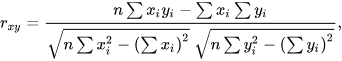

Using for a pair of colunms, A and B, this test computes a correlation coefficient on the real and synthetic data, R and S. This yields two separate correlation values. The test normalizes and returns a similarity score using the formula below.

$score = 1 - \dfrac{|S_{A,B}-R_{A,B}|}{2}$

In [6]:
data_original = data_original.select_dtypes(include=['number'])
data_ctgan = data_ctgan.select_dtypes(include=['number'])
data_datasynthesizer = data_datasynthesizer.select_dtypes(include=['number'])
data_tvae = data_tvae.select_dtypes(include=['number'])

In [7]:
evaluator_ctgan = SyntheticDataEvaluator(data_original, data_ctgan)
evaluator_datasynthesizer = SyntheticDataEvaluator(data_original, data_datasynthesizer)
evaluator_tvae = SyntheticDataEvaluator(data_original, data_tvae)

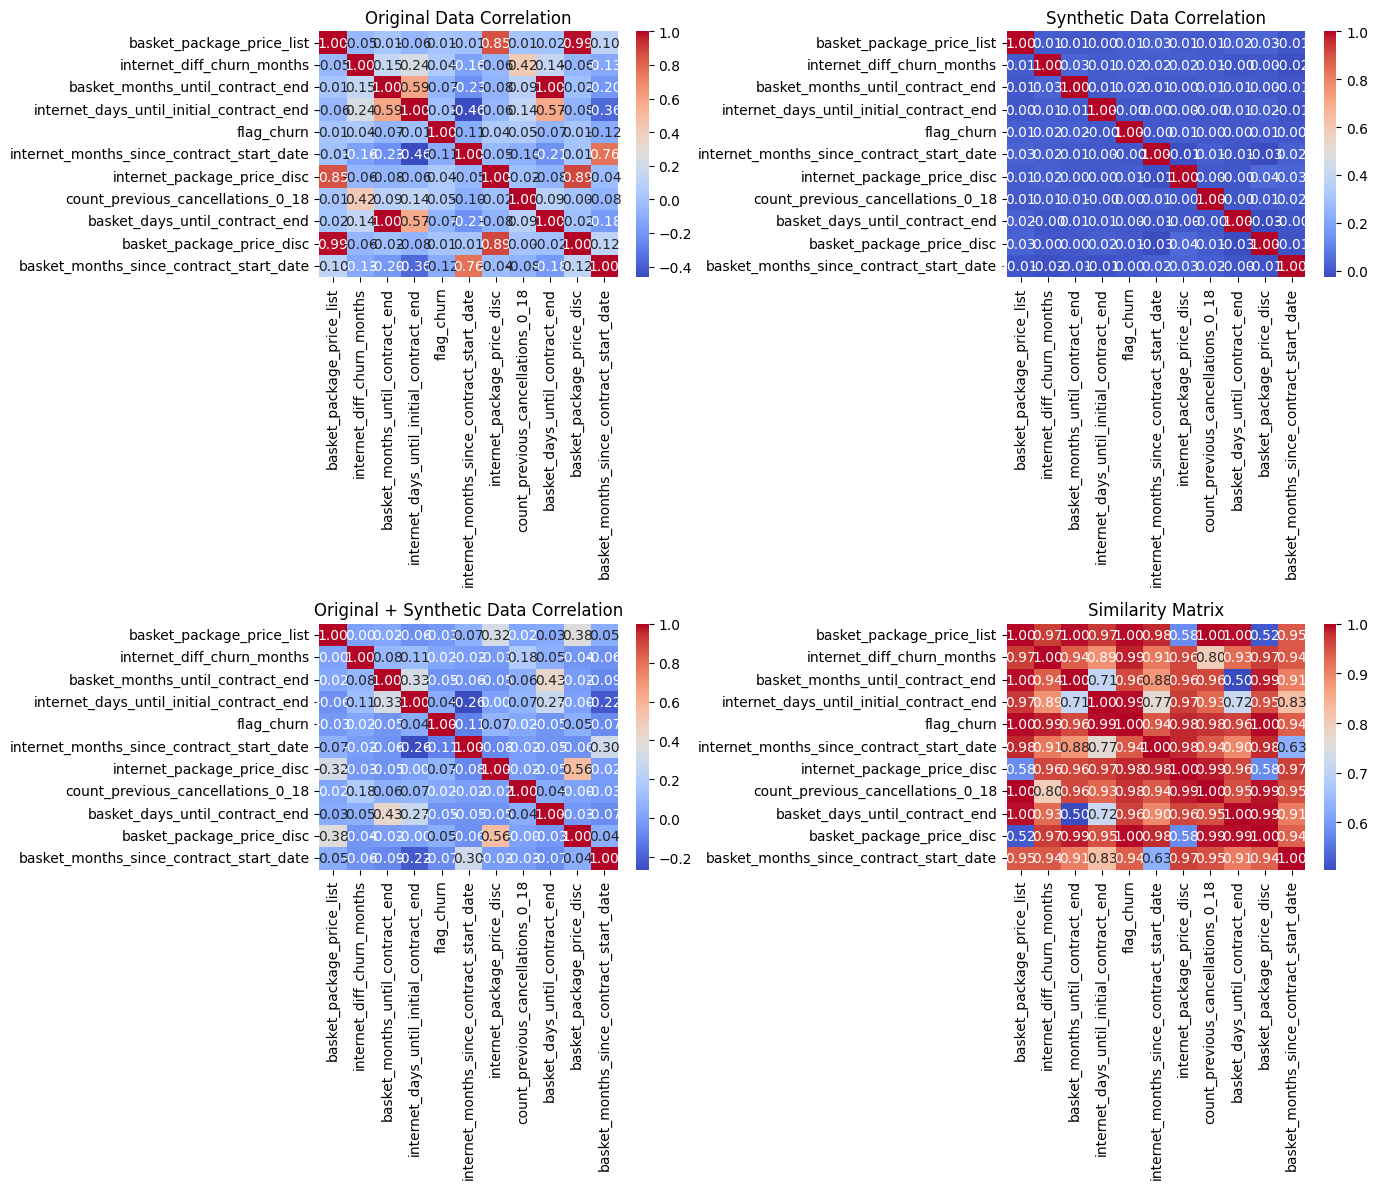

In [65]:
evaluator_ctgan.pc()

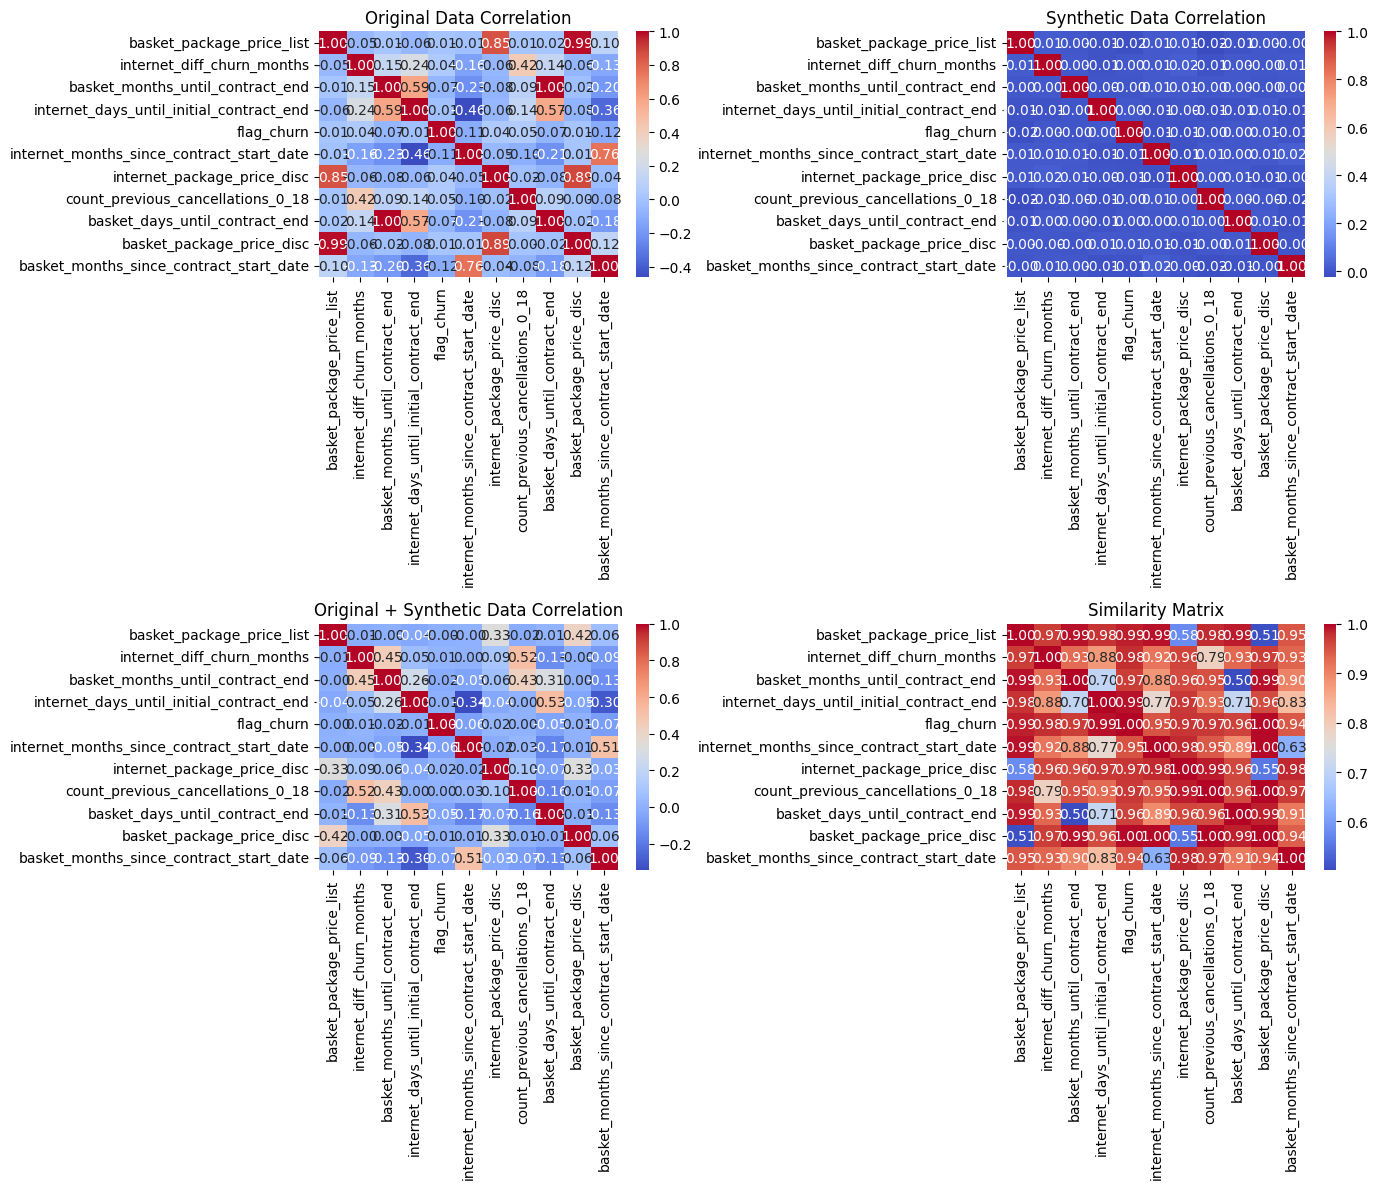

In [66]:
evaluator_datasynthesizer.pc()

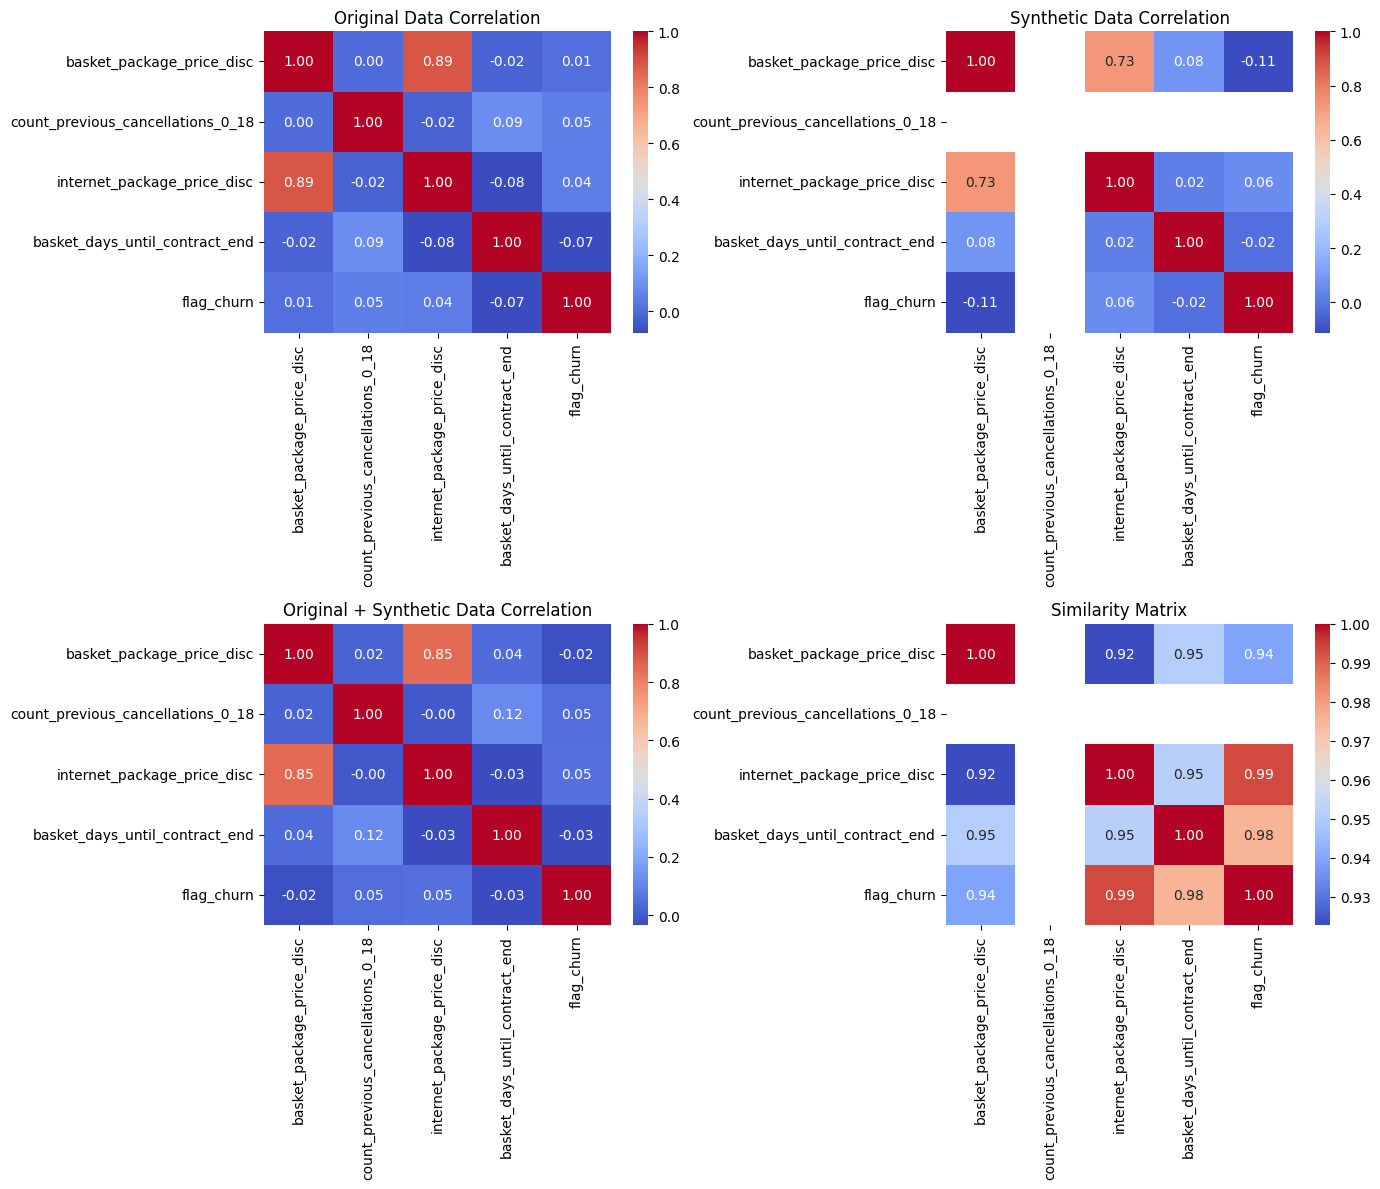

In [8]:
evaluator_tvae.pc()

# Kolmogorov-Smirnov test (KS)

We used Kolmogorov-Smirnov test to measure the quality of the synthetic data on continous columns. The test is a statistical hypothesis test that is used to determine whether two sets of data come from the same probability distribution or not.
The test is based on the maximum difference between the empirical cumulative distribution functions (ECDFs) of the twodatasets. The ECDF of a dataset is a step function that gives the proportion of data points that are less than or equal to a given value. The test statistics, denoted by D, is the maximum absolute difference between the two ECDFs:

$\ D = max|F_1(x) - F_2(x)|$

where $\ F_1(x), F_2(x)$ are the ECDFs of the two datasets, and the x is the value at which the difference is evaluated. 

The null hypothesis of the test is that the two datasets come from the same distribution, and the alternative hypothesis is that they come from different distribution. The p-value of the test is computed as the probability of observing a test statistic as extreme as D under the null hypothesis. 

If the p-value is smaller than a chosen significance level, typically 0.05 or 0.01, then the null hypothesis is rejected in favor of the alternative hypothesis.

In [ ]:
data_original = data_original.select_dtypes(include=['number'])
data_ctgan = data_ctgan.select_dtypes(include=['number'])
data_datasynthesizer = data_datasynthesizer.select_dtypes(include=['number'])
data_tvae = data_tvae.select_dtypes(include=['number'])

In [ ]:
evaluator_ctgan = SyntheticDataEvaluator(data_original, data_ctgan)
evaluator_datasynthesizer = SyntheticDataEvaluator(data_original, data_datasynthesizer)
evaluator_tvae = SyntheticDataEvaluator(data_original, data_tvae)

In [69]:
evaluator_ctgan.kst()

,Columns,KS Statistics,p-value
0,basket_package_price_list,0.2358,0.0000
1,internet_diff_churn_months,0.0255,0.0030
2,basket_months_until_contract_end,0.1047,0.0000
3,internet_days_until_initial_contract_end,0.7696,0.0000
4,flag_churn,0.2279,0.0000
5,internet_months_since_contract_start_date,0.2589,0.0000
6,internet_package_price_disc,0.2324,0.0000
7,count_previous_cancellations_0_18,0.0448,0.0000
8,basket_days_until_contract_end,0.2976,0.0000
9,basket_package_price_disc,0.2422,0.0000


In [70]:
evaluator_datasynthesizer.kst()

/opt/conda/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


,Columns,KS Statistics,p-value
0,basket_package_price_list,0.2319,0.0000
1,internet_diff_churn_months,0.9168,0.0000
2,basket_months_until_contract_end,0.6375,0.0000
3,internet_days_until_initial_contract_end,0.6944,0.0000
4,flag_churn,0.0015,1.0000
5,internet_months_since_contract_start_date,0.1789,0.0000
6,internet_package_price_disc,0.3793,0.0000
7,count_previous_cancellations_0_18,0.8389,0.0000
8,basket_days_until_contract_end,0.3665,0.0000
9,basket_package_price_disc,0.2175,0.0000


In [71]:
evaluator_tvae.kst()

,Columns,KS Statistics,p-value
0,basket_package_price_list,0.0783,0.0000
1,internet_diff_churn_months,0.0553,0.0000
2,basket_months_until_contract_end,0.0397,0.0000
3,internet_days_until_initial_contract_end,0.0553,0.0000
4,flag_churn,0.0119,0.4784
5,internet_months_since_contract_start_date,0.1080,0.0000
6,internet_package_price_disc,0.1154,0.0000
7,count_previous_cancellations_0_18,0.0524,0.0000
8,basket_days_until_contract_end,0.2497,0.0000
9,basket_package_price_disc,0.1242,0.0000


# Total Variation Distance (TVD)

We calculated the Total Variation Distance to determine quality of the synthetic data on categorical columns. This test computes the Total Variation Distance (TVD) between the real and synthetic colunms. To do this, it first computes the frequency of each category value and axpresses it as a probability. The TVD statistic compares the difference in probabilities, as shown in the formula below::

$\delta(R, S) = {\dfrac{1}{2}}\sum_{\omega \in \Omega}|R_{\omega} - S_{\omega}|$

Here $\omega$ describes all the possible categories in a column $\Omega$. Meanwhile, R and S refer to the real and synthetic frequencies for those categories. The TVComplement returns 1-TVD so that a higher score means higher quality.

$score = 1 - \delta(R, S)$

In [73]:
data_original = data_original.select_dtypes(include=['object', 'category'])
data_ctgan = data_ctgan.select_dtypes(include=['object', 'category'])
data_datasynthesizer = data_datasynthesizer.select_dtypes(include=['object', 'category'])
data_tvae = data_tvae.select_dtypes(include=['object', 'category'])

In [74]:
evaluator_ctgan = SyntheticDataEvaluator(data_original, data_ctgan)
evaluator_datasynthesizer = SyntheticDataEvaluator(data_original, data_datasynthesizer)
evaluator_tvae = SyntheticDataEvaluator(data_original, data_tvae)

In [76]:
evaluator_ctgan.tvd()

,Columns,TVD
0,customer_age_class,0.0764
1,internet_product_name,0.1731
2,region,0.0802
3,basket_product_category,0.2354


In [77]:
evaluator_datasynthesizer.tvd()

,Columns,TVD
0,customer_age_class,0.2217
1,internet_product_name,0.7493
2,region,0.1593
3,basket_product_category,0.7703


In [78]:
evaluator_tvae.tvd()

,Columns,TVD
0,customer_age_class,0.4114
1,internet_product_name,0.1901
2,region,0.3716
3,basket_product_category,0.1327


# Overall Quality Score

We boil down the KS score and TVD score into one metric by taking the average across the scores in all columns. We call this column shape similarity. We also take the average of the correlation of all nuemric column pairs as the Correlation Similarity score.

Nearest Neighbour distance ratio (NNDR)?

In [1]:
import pandas as pd

# Change accordingly
synthetic = pd.read_csv('../GReaT/synthetic_data_test.csv')
original = pd.read_csv('../GReaT/synthetic_data_test.csv')

from metrics import SyntheticDataEvaluator

In [2]:
evaluator = SyntheticDataEvaluator(original, synthetic)

In [3]:
evaluator.tvd()

,Columns,TVD
0,vodafone_stars,0.0000
